## 准备数据

In [ ]:
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # or any {'0', '1', '2'}

def mnist_dataset():
    # 定义数据转换，包括将图像转换为张量
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    # 下载并加载 MNIST 训练集
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    train_data = train_dataset.data
    train_labels = train_dataset.targets

    # 下载并加载 MNIST 测试集
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    test_data = test_dataset.data
    test_labels = test_dataset.targets

    train_data = train_data / 255.0
    train_data = train_data.reshape(-1, 28*28)
    test_data = test_data / 255.0
    test_data = test_data.reshape(-1, 28*28)
    
    return (train_data, train_labels), (test_data, test_labels)


In [2]:
print(list(zip([1, 2, 3, 4], ['a', 'b', 'c', 'd'])))

[(1, 'a'), (2, 'b'), (3, 'c'), (4, 'd')]


## 建立模型

In [3]:
import torch.nn as nn
import torch.optim as optimizers
import torch.nn.functional as F

class myModel(nn.Module):
    def __init__(self):
        ####################
        '''声明模型对应的参数'''
        super(myModel, self).__init__()
        self.fc1 = nn.Linear(784, 100)
        self.fc2 = nn.Linear(100, 10)
        ####################
    def forward(self, x):
        ####################
        '''定义模型的前向传播'''
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
        ####################
        
model = myModel()

optimizer = optimizers.Adam(model.parameters(), lr=0.01)

## 计算 loss

In [13]:
lossfuction = nn.MSELoss()

def compute_loss(output, target):
    return lossfuction(output, target)

def compute_accuracy(output, target):
    predictions = torch.argmax(output, dim=1)
    labels = torch.argmax(target, dim=1)
    return torch.sum(predictions == labels).item() / float(labels.size(0))  

def train_one_step(model, optimizer, x, y):
    optimizer.zero_grad() # 清空梯度缓存
    output = model(x)
    loss = compute_loss(output, y)
    loss.backward()
    # 更新权重
    optimizer.step()
    # # 简单实现权重的更新
    # learning_rate = 0.01
    # for f in model.parameters():
    #     f.data.sub_(f.grad.data * learning_rate)

    accuracy = compute_accuracy(output, y)

    # loss and accuracy is scalar tensor
    return loss, accuracy

def test(model, x, y):
    output = model(x)
    loss = compute_loss(output, y)
    accuracy = compute_accuracy(output, y)
    return loss, accuracy

## 实际训练

In [14]:
train_data, test_data = mnist_dataset()
train_label = np.zeros(shape=[train_data[0].shape[0], 10])
test_label = np.zeros(shape=[test_data[0].shape[0], 10])
train_label[np.arange(train_data[0].shape[0]), np.array(train_data[1])] = 1.
test_label[np.arange(test_data[0].shape[0]), np.array(test_data[1])] = 1.

# 将数据转换为 PyTorch 浮点型张量
train_data = torch.tensor(train_data[0], dtype=torch.float32)
train_label = torch.tensor(train_label, dtype=torch.float32)
test_data = torch.tensor(test_data[0], dtype=torch.float32)
test_label = torch.tensor(test_label, dtype=torch.float32)

for epoch in range(50):
    loss, accuracy = train_one_step(model, optimizer, train_data, train_label)
    print('epoch', epoch, ': loss', loss.detach().numpy(), '; accuracy', accuracy)

# 测试模型
loss, accuracy = test(model, test_data, test_label)
print('test loss', loss.detach().numpy(), '; accuracy', accuracy)

C:\Users\覃声\AppData\Local\Temp\ipykernel_20184\519254540.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_data = torch.tensor(train_data[0], dtype=torch.float32)
C:\Users\覃声\AppData\Local\Temp\ipykernel_20184\519254540.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_data = torch.tensor(test_data[0], dtype=torch.float32)


epoch 0 : loss 0.050594192 ; accuracy 0.79335
epoch 1 : loss 0.07584733 ; accuracy 0.837
epoch 2 : loss 0.8301042 ; accuracy 0.26143333333333335
epoch 3 : loss 0.11584027 ; accuracy 0.48795
epoch 4 : loss 0.12635179 ; accuracy 0.29073333333333334
epoch 5 : loss 0.117842056 ; accuracy 0.37025
epoch 6 : loss 0.08738912 ; accuracy 0.49643333333333334
epoch 7 : loss 0.072314076 ; accuracy 0.5405833333333333
epoch 8 : loss 0.06432618 ; accuracy 0.6449333333333334
epoch 9 : loss 0.05918268 ; accuracy 0.71855
epoch 10 : loss 0.05627061 ; accuracy 0.7172833333333334
epoch 11 : loss 0.05416258 ; accuracy 0.7260833333333333
epoch 12 : loss 0.05100522 ; accuracy 0.7602
epoch 13 : loss 0.047317535 ; accuracy 0.79855
epoch 14 : loss 0.044152293 ; accuracy 0.82545
epoch 15 : loss 0.04151461 ; accuracy 0.8423666666666667
epoch 16 : loss 0.039409745 ; accuracy 0.8549166666666667
epoch 17 : loss 0.03758064 ; accuracy 0.8646333333333334
epoch 18 : loss 0.035351917 ; accuracy 0.8721166666666667
epoch 19 

# 样例演示 输出错误样例

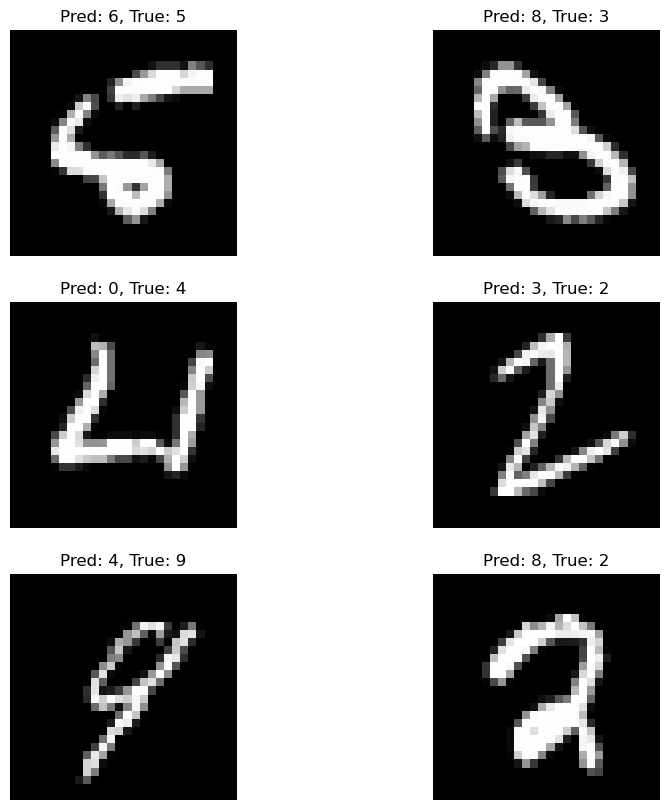

In [15]:
output = model(test_data)
predictions = torch.argmax(output, dim=1)
labels = torch.argmax(test_label, dim=1)

# 找到错误分类的样例
incorrect_samples = (predictions != labels).nonzero(as_tuple=True)[0]

import matplotlib.pyplot as plt
# 显示 6 个错误分类的样例图像
num_samples_to_show = 6
plt.figure(figsize=(10, 10))
for i in range(min(num_samples_to_show, len(incorrect_samples))):
    idx = incorrect_samples[i].item()
    plt.subplot(3, 2, i + 1)
    plt.imshow(test_data[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predictions[idx].item()}, True: {labels[idx].item()}")
    plt.axis('off')
plt.show()